In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# official index: England and Wales, rebased to Jan 1995 = 100
hpi = pd.read_csv("data/raw/uk_hpi_indices_2026-07.csv", parse_dates=["Date"])
ew = (
    hpi.loc[hpi["Region_Name"] == "England and Wales"]
    .set_index("Date")["Index"]
    .sort_index()
)
ew = 100 * ew / ew.loc["1995-01-01"]
ew.name = "UK HPI (England and Wales)"

# your benchmark index
rs = pd.read_csv("data/processed/bmn_index_case_shiller_min24m.csv",
                 index_col="month", parse_dates=True).iloc[:, 0]
rs.name = "Repeat-sales (Case-Shiller, holds ≥ 2y)"

# align on the months both cover
both = pd.concat([ew, rs], axis=1, join="inner")
print(both.index.min(), both.index.max(), len(both))

1995-01-01 00:00:00 2026-06-01 00:00:00 378


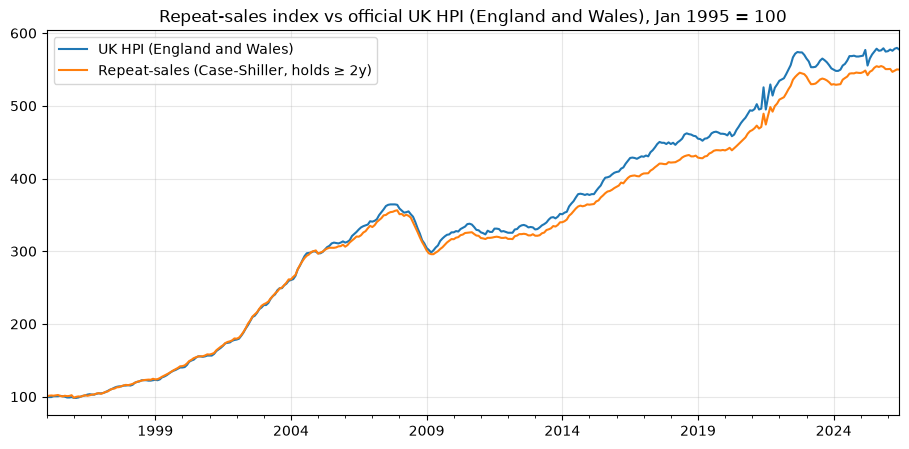

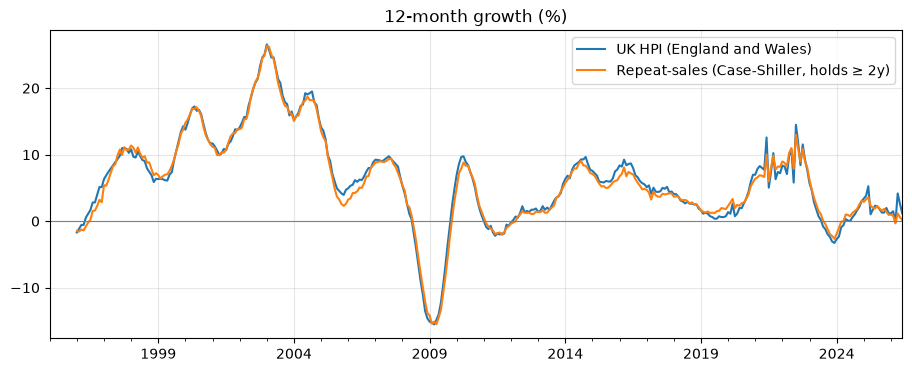

Final level ratio: 0.9520570235203601
Growth correlation: 0.9929961590621521


In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
both.plot(ax=ax)
ax.set_title("Repeat-sales index vs official UK HPI (England and Wales), Jan 1995 = 100")
ax.grid(alpha=0.3)
plt.show()

growth = 100 * (both / both.shift(12) - 1)
fig, ax = plt.subplots(figsize=(11, 4))
growth.plot(ax=ax)
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_title("12-month growth (%)")
ax.grid(alpha=0.3)
plt.show()

print("Final level ratio:", both.iloc[-1, 1] / both.iloc[-1, 0])
print("Growth correlation:", growth.corr().iloc[0, 1])